In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

In [2]:
# step 1: for each method, extract the mean s_per_step from the training dynamics.
save_freq = 10
timings = { # approximate
    "qwen_2.5_7b_grpo" : 1000 * save_freq,
    "qwen_2.5_7b_kl-cov" : 1400 * save_freq,
    "qwen_2.5_7b_dapo" : 2200 * save_freq,
    "qwen_2.5_7b_grpo-s" : 1100 * save_freq
}

In [3]:
path = "/ptmp/rfechner/out/exp08"
methods = os.listdir(path)
methods

['reasoning_types__qwen2.5_7b__kl-cov',
 'reasoning_strategies__qwen2.5_7b__dapo',
 'error_types__qwen2.5_7b__grpo',
 'reasoning_types__qwen2.5_7b__grpo',
 'reasoning_strategies__qwen2.5_7b__grpo',
 'reasoning_strategies__qwen2.5_7b__grpo-s',
 'error_types__qwen2.5_7b__grpo-s',
 'reasoning_strategies__qwen2.5_7b__kl-cov',
 'error_types__qwen2.5_7b__kl-cov',
 'reasoning_types__qwen2.5_7b__grpo-s',
 'error_types__qwen2.5_7b__dapo',
 'reasoning_types__qwen2.5_7b__dapo']

In [4]:
rs_paths = list(filter(lambda x: x.startswith('reasoning_strategies'), methods))
rt_paths = list(filter(lambda x: x.startswith('reasoning_types'), methods))
es_paths = list(filter(lambda x: x.startswith('error_types'), methods))
rs_paths, rt_paths, es_paths

(['reasoning_strategies__qwen2.5_7b__dapo',
  'reasoning_strategies__qwen2.5_7b__grpo',
  'reasoning_strategies__qwen2.5_7b__grpo-s',
  'reasoning_strategies__qwen2.5_7b__kl-cov'],
 ['reasoning_types__qwen2.5_7b__kl-cov',
  'reasoning_types__qwen2.5_7b__grpo',
  'reasoning_types__qwen2.5_7b__grpo-s',
  'reasoning_types__qwen2.5_7b__dapo'],
 ['error_types__qwen2.5_7b__grpo',
  'error_types__qwen2.5_7b__grpo-s',
  'error_types__qwen2.5_7b__kl-cov',
  'error_types__qwen2.5_7b__dapo'])

In [5]:
es_paths_abs = [os.path.join(path, r) for r in es_paths]
rs_paths_abs = [os.path.join(path, r) for r in rs_paths]
rt_paths_abs = [os.path.join(path, r) for r in rt_paths]

In [6]:
def collect_data_new_schema(paths: list[str]) -> dict:
    """
    Collects data from multiple methods/checkpoints.

    For each checkpoint, it returns:
      - aggregated means per behaviour type (lp and e)
      - a 'raw' DataFrame per checkpoint containing per-example statistics:
            'behaviour_type', 'base_lp', 'lpdelta', 'entdelta'
    """
    per_methods = {}

    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = [f for f in os.listdir(validation_dir_path) if f.endswith('_precomp.jsonl')]
        precomp_files = sorted(precomp_files, key=lambda x: int(x.split("_")[0]))

        checkpoints = []
        for pfile in precomp_files: # iterates over the checkpoints
            df = pd.read_json(os.path.join(validation_dir_path, pfile), lines=True)

            # Compute per-row means
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)

            rows = []
            raw_rows = []  # store per-example statistics for binning
            for index, group_df in df.groupby('index'):
                # find anchor
                anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                other_rows = group_df[group_df['behaviour_type'] != 'anchor']

                # subtract others from anchor
                lpdelta =  other_rows['lpmean'].to_numpy() - anchor_row['lpmean'].to_numpy()
                entdelta =  other_rows['entmean'].to_numpy() - anchor_row['lpmean'].to_numpy()

                for bt, l, e, base in zip(other_rows['behaviour_type'], lpdelta, entdelta, other_rows['lpmean']):
                    rows.append({'behaviour_type': bt, 'lp': l, 'e': e})
                    raw_rows.append({'behaviour_type': bt, 'base_lp': base, 'lpdelta': l, 'entdelta': e})

            # Create aggregated mean DataFrame
            new_df = pd.DataFrame(rows)
            means: pd.DataFrame = new_df.groupby('behaviour_type').mean()

            # Store checkpoint data with raw info
            checkpoint_data = {
                'lp': means['lp'].to_dict(),
                'e': means['e'].to_dict(),
                'raw': pd.DataFrame(raw_rows)  # needed for binning
            }
            checkpoints.append(checkpoint_data)

        per_methods[method] = checkpoints

    return per_methods

In [7]:
data = collect_data_new_schema(rt_paths_abs)

In [8]:
from typing import Literal
def plot_bin(
    data: dict,
    by: Literal['base_likelihood', 'delta'] = 'delta',
    time_per_step_s: dict[str, int] | None = None
):
    """
    Simple binned ΔLog-prob plot (or base_likelihood), comparing methods.
    
    Bins are fixed:
        [-10, -5, -2, -1, 0, 1, 2, 5, 10]
    """

    # -------------------------------
    # Select key to bin by
    # -------------------------------
    if by == "delta":
        value_key = "lpdelta"
    elif by == "base_likelihood":
        value_key = "lp"
    else:
        raise ValueError(f"Unknown 'by' parameter: {by}")

    # We always use fixed bins
    bins = np.array([0, 1, 2, 3])

    # -------------------------------
    # Collect behaviour types
    # -------------------------------
    behaviour_types = sorted({
        key
        for method_records in data.values()
        for rec in method_records
        for key in rec.get("lp", {}).keys()
    })
    methods = list(data.keys())

    # -------------------------------
    # Precompute per-method binned DataFrames
    # -------------------------------
    binned_data = {}   # method -> list of DataFrames
    for method, records in data.items():
        method_list = []
        for rec in records:
            if "raw" not in rec:
                continue
            df = rec["raw"].copy()
            if value_key not in df:
                continue

            # Compute bin index with np.digitize
            df["bin"] = np.digitize(np.abs(df[value_key]), bins, right=True) - 1
            df["bin"] = df["bin"].clip(0, len(bins) - 2)

            # Mean per behaviour/bin
            grouped = (
                df.groupby(["behaviour_type", "bin"], observed=False)[value_key]
                .mean()
                .reset_index()
            )
            method_list.append(grouped)
        binned_data[method] = method_list

    n_bins_actual = len(bins) - 1
    n_behaviours = len(behaviour_types)

    if n_bins_actual == 0 or n_behaviours == 0:
        print("[plot_bin] ⚠️ No bins or behaviour types found. Check your data.")
        return

    # -------------------------------
    # Create figure
    # -------------------------------
    fig, axes = plt.subplots(
        n_bins_actual, n_behaviours,
        figsize=(5 * n_behaviours, 2.3 * n_bins_actual),
        squeeze=False
    )

    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    # Bin labels
    bin_labels = [f" $\\Delta \\in$ [{bins[i]} , {bins[i+1]}]" for i in range(n_bins_actual)]

    # -------------------------------
    # Plot
    # -------------------------------
    for bi in range(n_bins_actual):
        for col, beh in enumerate(behaviour_types):
            ax = axes[bi, col]

            for m_idx, method in enumerate(methods):
                lp_vals = []
                method_records = binned_data[method]

                for rec in method_records:
                    subset = rec[(rec["behaviour_type"] == beh) & (rec["bin"] == bi)]
                    lp_vals.append(
                        subset[value_key].mean() if not subset.empty else np.nan
                    )

                # X-axis
                if time_per_step_s and method in time_per_step_s:
                    t = np.arange(len(method_records)) * time_per_step_s[method]
                    xlabel = "Elapsed time (s)"
                else:
                    t = np.arange(len(method_records))
                    xlabel = "Checkpoint index"

                ax.plot(
                    t, lp_vals,
                    marker=markers[m_idx % len(markers)],
                    color=colors[m_idx],
                    lw=1, markersize=3,
                    label=method
                )

            # Labels
            if col == 0:
                ax.set_ylabel(bin_labels[bi], fontsize=9)
            if bi == n_bins_actual - 1:
                ax.set_xlabel(xlabel, fontsize=9)
            if bi == 0:
                ax.set_title(beh, fontsize=12)

    # Legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc="upper right", ncol=len(methods), frameon=False)
    fig.suptitle(f"Binned by absolute {by.replace('_',' ')}, $\\Delta$ = $\\log p (aug) - \\log p(gt)$", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

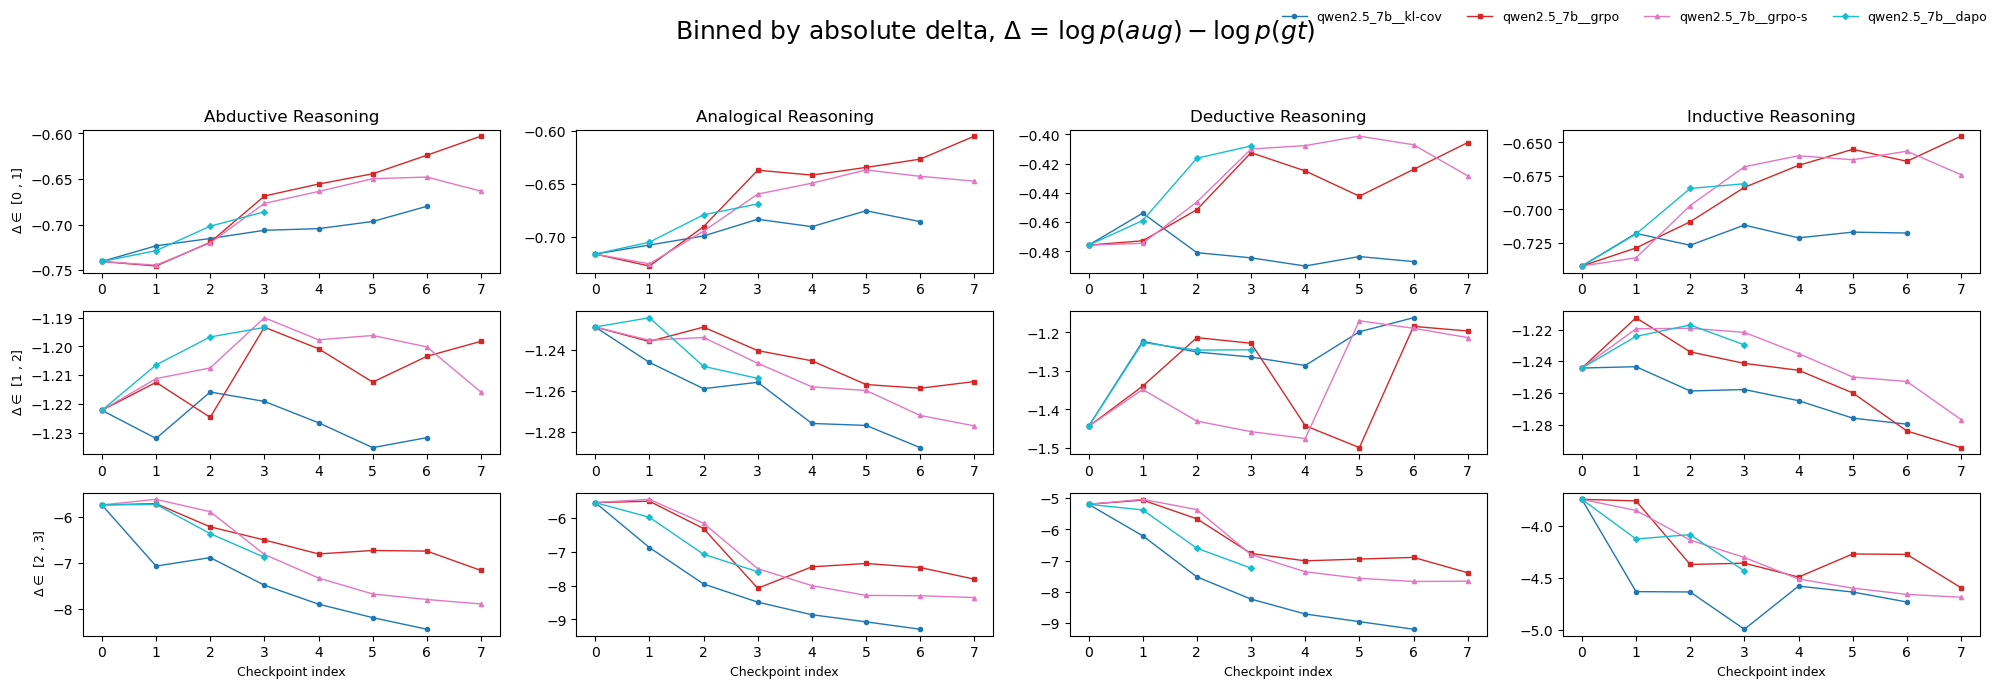

In [9]:
plot_bin(data, by='delta')

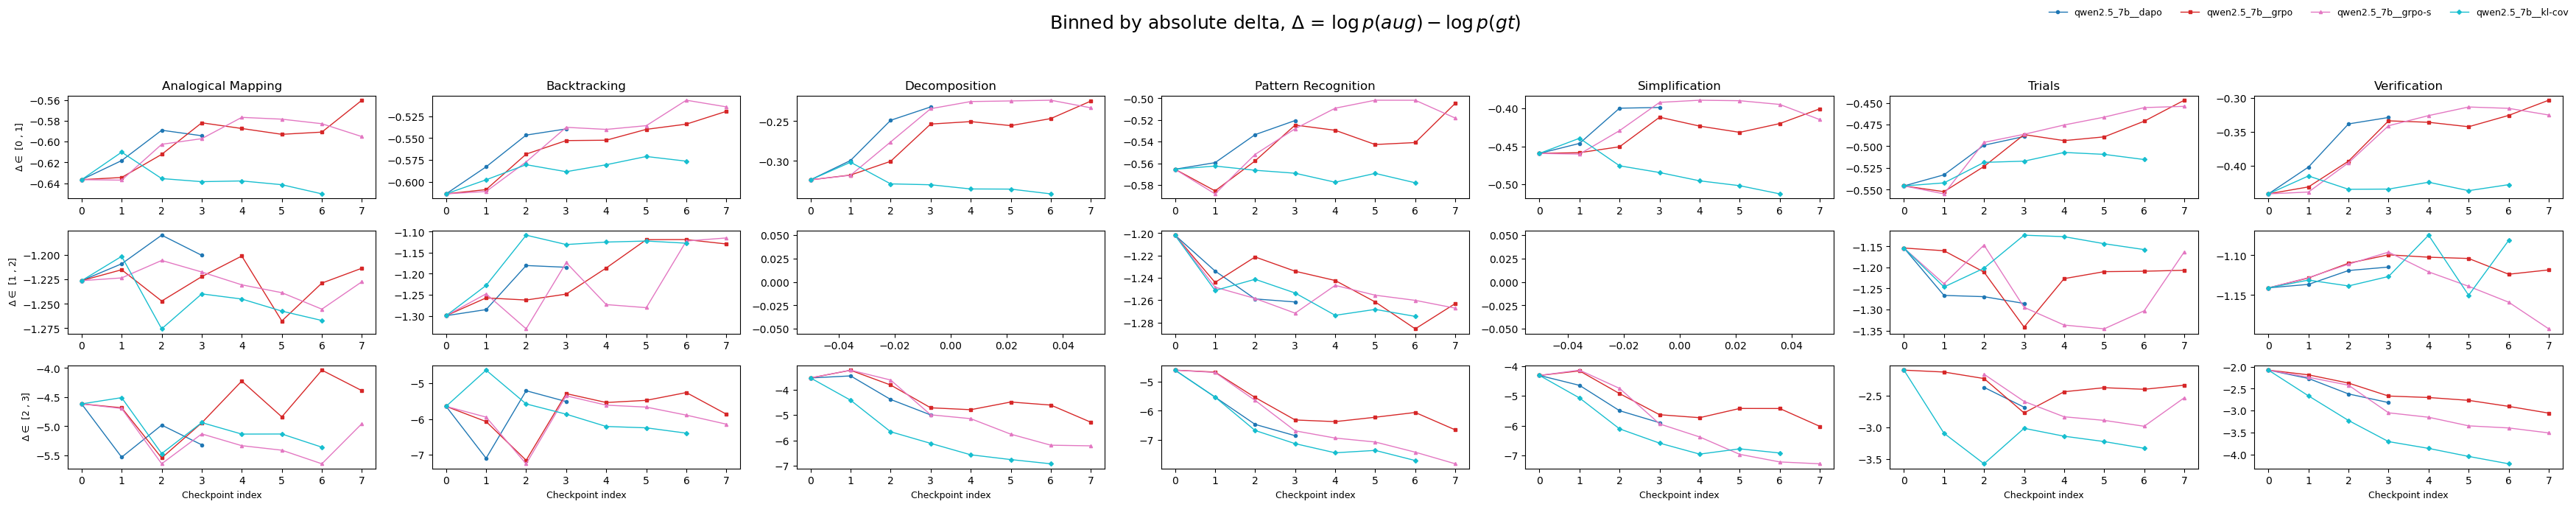

In [10]:
data_rs = collect_data_new_schema(rs_paths_abs)
plot_bin(data_rs, by='delta')

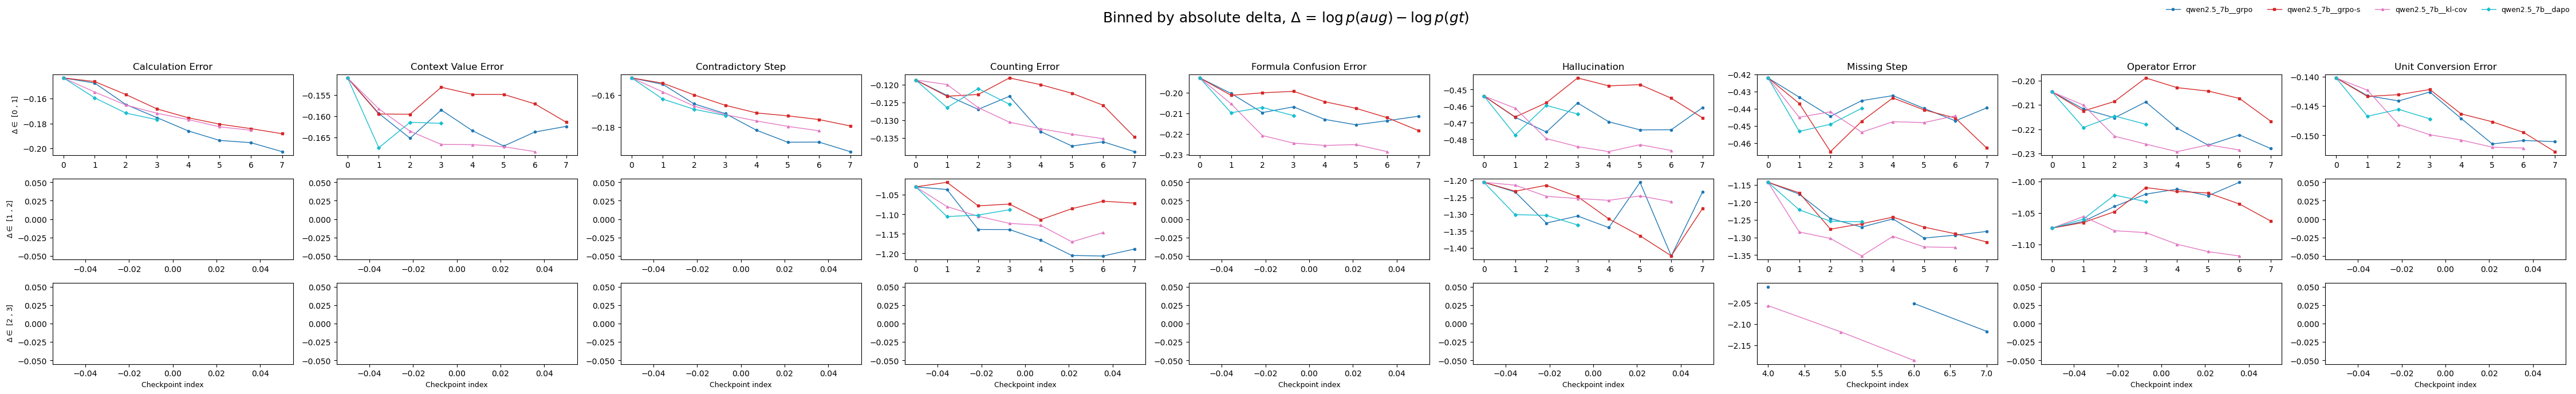

In [11]:
data_es = collect_data_new_schema(es_paths_abs)
plot_bin(data_es, by='delta')